# Olfaction basics

**Authors:** Sibo Wang-Chen, Thomas Ka Chung Lam

**Summary:** In this tutorial, we will implement a simple controller for odor-guided taxis.

The olfactory system in *Drosophila* consists of specialized olfactory sensory neurons (OSNs) located in the antennae and maxillary palps. These detect specific odorant molecules and convey this information to the brain's antennal lobe, where their signals are further processed. This is shown in the figure below (left, source: [Martin et al, 2013](https://doi.org/10.1002/ar.22747)). We emulated peripheral olfaction by attaching virtual odor sensors to the antennae and maxillary palps of our biomechanical model, as shown in the figure (right). The user can configure additional sensors at more precise locations on these olfactory organs. These virtual sensors can detect odor intensities across a multi-dimensional space that can be thought of as representing, for example, the concentrations of monomolecular chemicals sensed by OSNs in the antennae, or the intensities of composite odors co-activating numerous projection neurons in the antennal lobe.

<img src="https://github.com/NeLy-EPFL/_media/blob/main/flygym/olfaction_basics/olfaction.png?raw=true" width="700"/>

## Odor arena

To demonstrate odor sensing, let's create an environment with one attractive odor source and two aversive odor sources. The odor space has 2 dimensions (attractive, aversive) despite 3 physical sources. Each source has a peak intensity of 1. We color the attractive source orange and the aversive sources blue.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange

from flygym.compose import ActuatorType
from flygym.compose.world import FlatGroundWorld, OdorMixin
from flygym.examples.locomotion import TurningController
from utils import create_fly, create_simulation, show_video


class FlatGroundWorldWithOdorSources(OdorMixin, FlatGroundWorld):
    pass


world = FlatGroundWorldWithOdorSources()

odor_positions = np.array([[24, 0, 1.5], [8, -4, 1.5], [16, 4, 1.5]])
odor_peak_intensities = np.array([[1, 0], [0, 1], [0, 1]])
marker_colors = np.array(
    [[255, 127, 14], [31, 119, 180], [31, 119, 180]]
) / 255

for pos, peak_intensity, color in zip(
    odor_positions, odor_peak_intensities, marker_colors
):
    world.add_odor_source(
        pos=pos,
        peak_intensity=peak_intensity,
        marker_rgba=(*color, 1),
    )

In [8]:
fly = create_fly(enable_olfaction=True)
sim = create_simulation(
    fly, world, camera_kwargs={"pos": (odor_positions[:, 0].max() / 2, 0, 35)}
)
sim.step()
sim.render_as_needed()
show_video(sim)

"birdeyecam <source src=""data:video/mp4;base64,AAAAIGZ0eXBpc29tAAACAGlzb21pc28yYXZjMW1wNDEAAAAIZnJlZQAAAsZtZGF0AAACfwYF//973EXpvebZSLeWLNgg2SPu73gyNjQgLSBjb3JlIDE2NSByMzIyMyAwNDgwY2IwIC0gSC4yNjQvTVBFRy00IEFWQyBjb2RlYyAtIENvcHlsZWZ0IDIwMDMtMjAyNSAtIGh0dHA6Ly93d3cudmlkZW9sYW4ub3JnL3gyNjQuaHRtbCAtIG9wdGlvbnM6IGNhYmFjPTEgcmVmPTMgZGVibG9jaz0xOjA6MCBhbmFseXNlPTB4MzoweDExMyBtZT1oZXggc3VibWU9NyBwc3k9MSBwc3lfcmQ9MS4wMDowLjAwIG1peGVkX3JlZj0xIG1lX3JhbmdlPTE2IGNocm9tYV9tZT0xIHRyZWxsaXM9MSA4eDhkY3Q9MSBjcW09MCBkZWFkem9uZT0yMSwxMSBmYXN0X3Bza2lwPTEgY2hyb21hX3FwX29mZnNldD0tMiB0aHJlYWRzPTcgbG9va2FoZWFkX3RocmVhZHM9MSBzbGljZWRfdGhyZWFkcz0wIG5yPTAgZGVjaW1hdGU9MSBpbnRlcmxhY2VkPTAgYmx1cmF5X2NvbXBhdD0wIGNvbnN0cmFpbmVkX2ludHJhPTAgYmZyYW1lcz0zIGJfcHlyYW1pZD0yIGJfYWRhcHQ9MSBiX2JpYXM9MCBkaXJlY3Q9MSB3ZWlnaHRiPTEgb3Blbl9nb3A9MCB3ZWlnaHRwPTIga2V5aW50PTI1MCBrZXlpbnRfbWluPTI1IHNjZW5lY3V0PTQwIGludHJhX3JlZnJlc2g9MCByYz1jcXAgbWJ0cmVlPTAgcXA9MjAgaXBfcmF0aW89MS40MCBwYl9yYXRpbz0xLjMwIGFxPTAAgAAAADdliIQA//70oPgU0GJjysxWvdiImDlA4OycM4dgAE/6amlnbtZt9YBLQAARsSPjK4LKQQEC9K6hAAADBW1vb3YAAABsbXZoZAAAAAAAAAAAAAAAAAAAA+gAAAAoAAEAAAEAAAAAAAAAAAAAAAABAAAAAAAAAAAAAAAAAAAAAQAAAAAAAAAAAAAAAAAAQAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAIAAAIwdHJhawAAAFx0a2hkAAAAAwAAAAAAAAAAAAAAAQAAAAAAAAAoAAAAAAAAAAAAAAAAAAAAAAABAAAAAAAAAAAAAAAAAAAAAQAAAAAAAAAAAAAAAAAAQAAAAAFAAAAA8AAAAAAAJGVkdHMAAAAcZWxzdAAAAAAAAAABAAAAKAAAAAAAAQAAAAABqG1kaWEAAAAgbWRoZAAAAAAAAAAAAAAAAAAAMgAAAAIAVcQAAAAAAC1oZGxyAAAAAAAAAAB2aWRlAAAAAAAAAAAAAAAAVmlkZW9IYW5kbGVyAAAAAVNtaW5mAAAAFHZtaGQAAAABAAAAAAAAAAAAAAAkZGluZgAAABxkcmVmAAAAAAAAAAEAAAAMdXJsIAAAAAEAAAETc3RibAAAAK9zdHNkAAAAAAAAAAEAAACfYXZjMQAAAAAAAAABAAAAAAAAAAAAAAAAAAAAAAFAAPAASAAAAEgAAAAAAAAAARVMYXZjNjIuMTEuMTAwIGxpYngyNjQAAAAAAAAAAAAAABj//wAAADVhdmNDAWQADf/hABhnZAANrNlBQfoQAAADABAAAAMDIPFCmWABAAZo6+GyyLD9+PgAAAAAFGJ0cnQAAAAAAAIkcAAAAAAAAAAYc3R0cwAAAAAAAAABAAAAAQAAAgAAAAAcc3RzYwAAAAAAAAABAAAAAQAAAAEAAAABAAAAFHN0c3oAAAAAAAACvgAAAAEAAAAUc3RjbwAAAAAAAAABAAAAMAAAAGF1ZHRhAAAAWW1ldGEAAAAAAAAAIWhkbHIAAAAAAAAAAG1kaXJhcHBsAAAAAAAAAAAAAAAALGlsc3QAAAAkqXRvbwAAABxkYXRhAAAAAQAAAABMYXZmNjIuMy4xMDA="" type=""video/mp4""/> This browser does not support the video tag."


## Controller for odor taxis

Let's design a simple hand-tuned controller for odor-guided taxis. We start by calculating the left–right asymmetry of the odor intensity $I$ for each odor dimension $o$:

$$
\Delta I_o = \frac{I_{\text{left},o} - I_{\text{right},o}}{(I_{\text{left},o} + I_{\text{right},o}) / 2}
$$

Then, we multiply $\Delta I_o$ by a gain $\gamma_o$ for each odor dimension and take the sum $s$. Attractive and aversive odors have different signs in their gains:

$$
s = \sum_{o} \gamma_o \,\Delta I_o
$$

We transform $s$ nonlinearly to avoid overly drastic turns when the asymmetry is subtle and to bound it within the range $[0, 1)$. This gives us a turning bias $b$:

$$
b = \tanh(s^2)
$$

Finally, we modulate the descending signal $\delta$ based on $b$ and the sign of $s$:

$$
\delta_\text{left} = 
    \begin{cases}
    \delta_\text{max} & \text{if } s > 0 \\
    \delta_\text{max} - b\,(\delta_\text{max} - \delta_\text{min})  & \text{otherwise}
    \end{cases}
    \qquad
    \delta_\text{right} = 
    \begin{cases}
    \delta_\text{max} - b\,(\delta_\text{max} - \delta_\text{min}) & \text{if } s > 0 \\
    \delta_\text{max}  & \text{otherwise}
    \end{cases}
$$

where $\delta_\text{min}$ and $\delta_\text{max}$ define the range of the descending signal. We use the following parameters:

- $\gamma_\text{attractive} = -500$ (negative ipsilateral gain leads to positive taxis)
- $\gamma_\text{aversive} = 80$ (positive ipsilateral gain leads to negative taxis)
- $\delta_\text{min} = 0.2$, $\delta_\text{max} = 1$

The steering signal is recalculated every 0.05 seconds. Let's implement this:

In [3]:
ATTRACTIVE_GAIN = -500
AVERSIVE_GAIN = 80
DECISION_INTERVAL = 0.05
RUN_TIME = 5

num_decision_steps = int(RUN_TIME / DECISION_INTERVAL)
physics_steps_per_decision = int(DECISION_INTERVAL / sim.timestep)

controller = TurningController(timestep=sim.timestep)
odor_history = []
fly_pos_history = []

with trange(num_decision_steps * physics_steps_per_decision) as pbar:
    for _ in range(num_decision_steps):
        odor_intensities = sim.get_olfaction(fly.name)

        attractive_intensities = np.average(
            odor_intensities[:, 0].reshape(2, 2), axis=0, weights=[9, 1]
        )
        aversive_intensities = np.average(
            odor_intensities[:, 1].reshape(2, 2), axis=0, weights=[10, 0]
        )
        attractive_bias = (
            ATTRACTIVE_GAIN
            * (attractive_intensities[0] - attractive_intensities[1])
            / attractive_intensities.mean()
        )
        aversive_bias = (
            AVERSIVE_GAIN
            * (aversive_intensities[0] - aversive_intensities[1])
            / aversive_intensities.mean()
        )
        effective_bias = aversive_bias + attractive_bias
        effective_bias_norm = np.tanh(effective_bias**2) * np.sign(effective_bias)
        assert np.sign(effective_bias_norm) == np.sign(effective_bias)

        control_signal = np.ones(2)
        side_to_modulate = int(effective_bias_norm > 0)
        modulation_amount = np.abs(effective_bias_norm) * 0.8
        control_signal[side_to_modulate] -= modulation_amount

        for _ in range(physics_steps_per_decision):
            joint_angles, adhesion = controller.step(control_signal)
            sim.set_actuator_inputs(fly.name, ActuatorType.POSITION, joint_angles)
            sim.set_actuator_inputs(fly.name, ActuatorType.ADHESION, adhesion)
            sim.step()
            sim.render_as_needed()
            odor_history.append(odor_intensities)

            fly_pos = sim.mj_data.body(f"{fly.name}/").xpos[:2].copy()
            fly_pos_history.append(fly_pos)

            if np.linalg.norm(fly_pos - odor_positions[0, :2]) < 2:
                break

            pbar.update()

odor_history = np.array(odor_history)
fly_pos_history = np.array(fly_pos_history)
show_video(sim)

 68%|██████▊   | 33769/50000 [02:21<01:08, 238.68it/s]


birdeyecam This browser does not support the video tag.


We can visualize the fly trajectory:

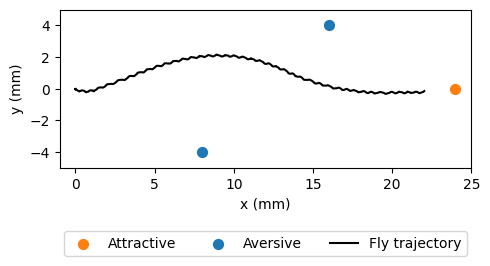

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4), tight_layout=True)
ax.scatter(
    odor_positions[0, 0], odor_positions[0, 1],
    marker="o", color="tab:orange", s=50, label="Attractive",
)
ax.scatter(
    odor_positions[1:, 0], odor_positions[1:, 1],
    marker="o", color="tab:blue", s=50, label="Aversive",
)
ax.plot(fly_pos_history[:, 0], fly_pos_history[:, 1], color="k", label="Fly trajectory")
ax.set_aspect("equal")
ax.set_xlim(-1, 25)
ax.set_ylim(-5, 5)
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.legend(ncols=3, loc="lower center", bbox_to_anchor=(0.5, -0.6))